# Delivery Demand Prediction: Exploratory Data Analysis

This notebook prepares delivery-logistics records for demand forecasting. It reviews data quality, standardizes data types, explores numeric distributions, and creates a daily aggregated dataset for modeling.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Load and inspect the dataset

Load the raw delivery-logistics data and review its structure before cleaning.

In [2]:
DATASET_PATH = "../dataset/delivery_logistics.csv"

In [3]:
dataset = pd.read_csv(DATASET_PATH)
dataset.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,delivery_date,expected_delivery_hours,actual_delivery_hours
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206,2025-01-17 16:39:00,8.8,8.4
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700,2025-03-21 12:51:00,2.5,2.1
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700,2025-01-16 15:12:00,7.6,7.0
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700,2025-01-18 13:58:00,8.1,7.9
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600,2025-05-14 16:43:00,7.1,6.8


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   delivery_id              25000 non-null  float64
 1   delivery_partner         25000 non-null  str    
 2   package_type             25000 non-null  str    
 3   vehicle_type             25000 non-null  str    
 4   delivery_mode            25000 non-null  str    
 5   region                   25000 non-null  str    
 6   weather_condition        25000 non-null  str    
 7   distance_km              25000 non-null  float64
 8   package_weight_kg        25000 non-null  float64
 9   delayed                  25000 non-null  str    
 10  delivery_status          25000 non-null  str    
 11  delivery_rating          25000 non-null  int64  
 12  delivery_cost            25000 non-null  float64
 13  delivery_date            25000 non-null  str    
 14  expected_delivery_hours  25000 no

## 3. Assess data quality

### Missing values

Check whether any columns contain missing values.

In [5]:
print(dataset.isna().sum())

delivery_id                0
delivery_partner           0
package_type               0
vehicle_type               0
delivery_mode              0
region                     0
weather_condition          0
distance_km                0
package_weight_kg          0
delayed                    0
delivery_status            0
delivery_rating            0
delivery_cost              0
delivery_date              0
expected_delivery_hours    0
actual_delivery_hours      0
dtype: int64


### Duplicate records

Check for duplicated rows, then examine the identifier column separately.

In [6]:
print(dataset.duplicated().sum())

0


In [7]:
# The source delivery_id is expected to be unique.

duplicate_count = dataset["delivery_id"].duplicated().sum()
duplicate_count

np.int64(498)

In [8]:
# Mark repeated identifiers while retaining the first occurrence.
is_duplicate = dataset["delivery_id"].duplicated()

In [9]:
# Display the rows containing repeated identifiers.
duplicated_rows = dataset[is_duplicate]
duplicated_rows[["delivery_id"]].head()

,delivery_id
1,250.99
2,250.99
3,250.99
4,250.99
5,250.99


In [10]:
# Assign a unique, sequential identifier to each delivery record.
dataset['delivery_id'] = "dlv-" + (dataset.index + 1).astype(str).str.zfill(4)

In [11]:
# Verify that the newly assigned identifiers are unique.
duplicate_count = dataset["delivery_id"].duplicated().sum()
duplicate_count

np.int64(0)

### Data types

Convert the delivery timestamp to a datetime value, categorical attributes to the `category` dtype, and the delay flag to a Boolean value.

In [12]:
dataset['delivery_date'] = pd.to_datetime(dataset['delivery_date'])

In [13]:
CATEGORICAL_COLS = [
    'delivery_partner', 'package_type', 'vehicle_type', 
    'delivery_mode', 'region', 'weather_condition', 
    'delivery_status'
]

for col in CATEGORICAL_COLS:
    dataset[col] = dataset[col].astype('category')

In [14]:
dataset['delayed'] = np.where(dataset['delayed'] == "yes", True, False)

## 4. Inspect numeric variables and outliers

Use summary statistics, box plots, and the interquartile range (IQR) rule to identify potential outliers. No observations are removed at this stage; the results inform later modeling decisions.

In [15]:
dataset.describe()

,distance_km,package_weight_kg,delivery_rating,delivery_cost,delivery_date,expected_delivery_hours,actual_delivery_hours
count,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,150.390436,25.145898,3.666000,864.944579,2025-04-01 13:09:43.684799,4.503484,4.829416
min,3.600000,0.670000,1.000000,95.667400,2025-01-01 06:03:00,0.500000,0.400000
25%,75.900000,12.680000,3.000000,490.800000,2025-02-15 03:31:45,2.400000,2.400000
50%,151.000000,25.145000,4.000000,867.535000,2025-04-01 13:59:00,4.500000,4.700000
75%,224.900000,37.660000,5.000000,1237.910000,2025-05-17 07:59:45,6.600000,7.100000
max,297.100000,49.520000,5.000000,1632.720600,2025-06-30 19:18:00,9.700000,12.800000
std,86.409745,14.368663,1.149964,435.712593,NaN,2.472114,2.857912


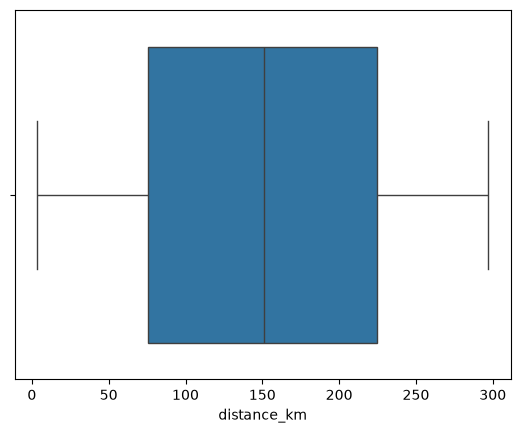

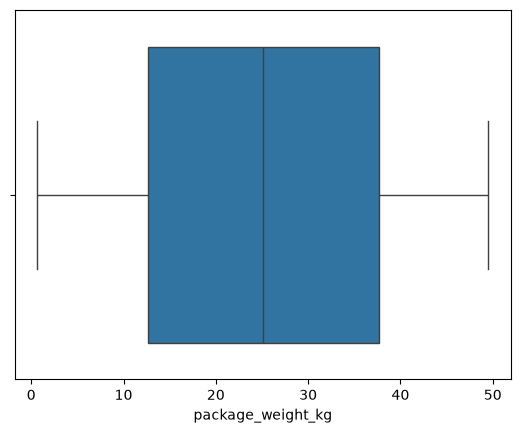

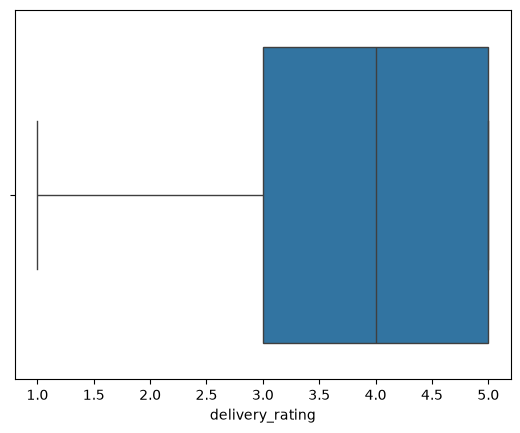

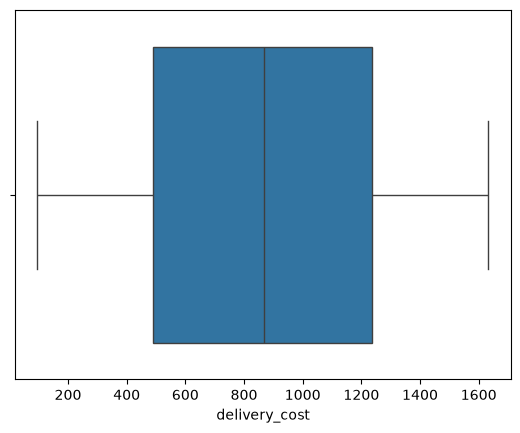

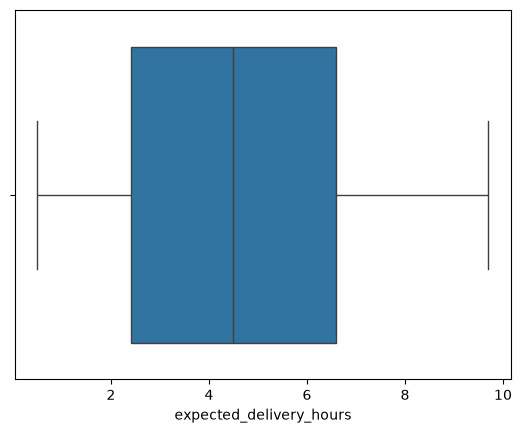

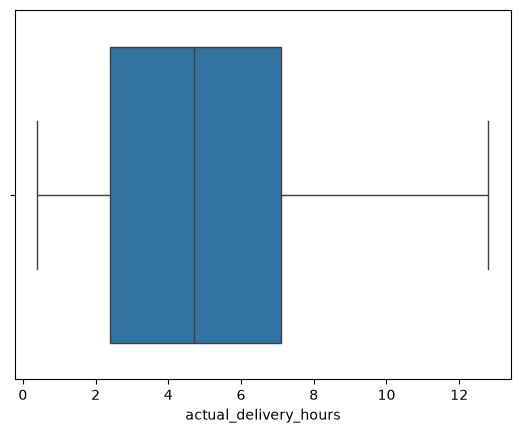

In [16]:
NUMERIC_COLS = [
    "distance_km", "package_weight_kg",	"delivery_rating",	
    "delivery_cost", "expected_delivery_hours",	"actual_delivery_hours"
]

for cols in NUMERIC_COLS:
    # Create the boxplot
    sns.boxplot(x=dataset[cols])
    
    # Display the plot
    plt.show()

In [17]:
# Calculate IQR-based bounds and count observations outside them.
for cols in NUMERIC_COLS:
    print(f"{cols.upper()}")
    Q1 = dataset[cols].quantile(0.25)
    Q3 = dataset[cols].quantile(0.75)
    IQR = Q3 - Q1
    
    # Anything below lower or above upper would be a circle
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Count how many outliers exist
    outlier_count = ((dataset[cols] < lower_limit) | (dataset[cols] > upper_limit)).sum()
    print(f"Total outliers: {outlier_count}\n")

DISTANCE_KM
Total outliers: 0

PACKAGE_WEIGHT_KG
Total outliers: 0

DELIVERY_RATING
Total outliers: 0

DELIVERY_COST
Total outliers: 0

EXPECTED_DELIVERY_HOURS
Total outliers: 0

ACTUAL_DELIVERY_HOURS
Total outliers: 0



### Correlation analysis

The heatmap below shows Pearson correlations between numeric variables. Use it to identify relationships that may be useful for forecasting and to flag strongly correlated inputs that could introduce redundancy in a model.

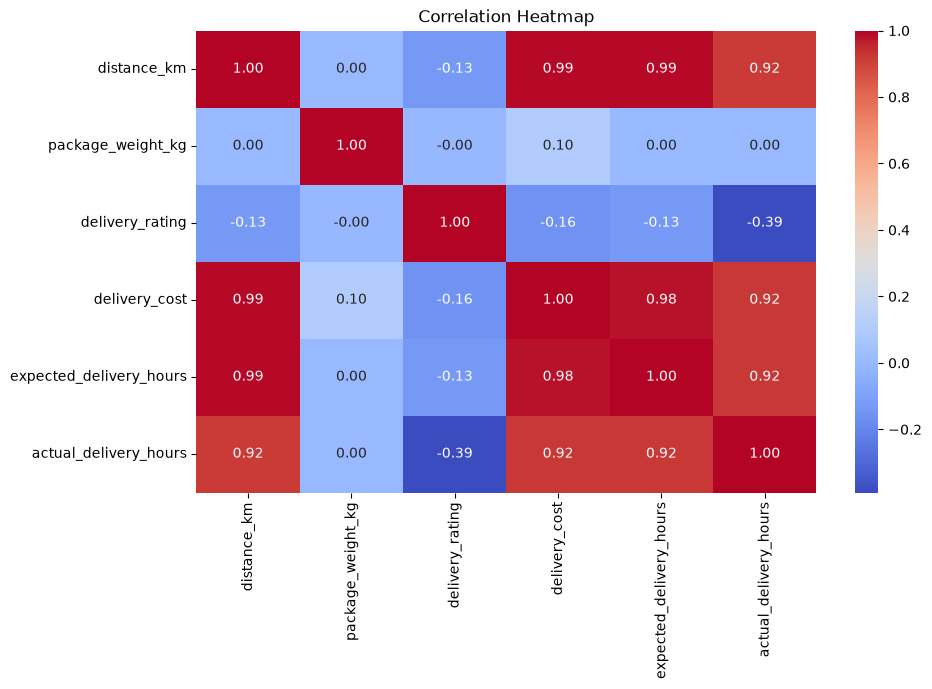

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(dataset[NUMERIC_COLS].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 5. Engineer features for demand forecasting

### Weather indicators

Create two binary weather features: one for unfavorable conditions (`rainy`, `stormy`, or `foggy`) and another for extreme temperatures (`hot` or `cold`).

In [19]:
dataset['is_unfavorable_weather'] = dataset['weather_condition'].isin(['rainy', 'stormy', 'foggy']).astype(int)
dataset['is_extreme_temp'] = dataset['weather_condition'].isin(['hot', 'cold']).astype(int)

### Select forecasting inputs

Retain the date, regional and weather indicators, delivery characteristics, and unique identifier needed to derive daily demand.

In [20]:
demand_features = [
    'delivery_date', 'region', 'is_unfavorable_weather', 
    'is_extreme_temp', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_delivery_hours', 'delivery_id',    
]

demand_df = dataset[demand_features]
demand_df.head()

,delivery_date,region,is_unfavorable_weather,is_extreme_temp,distance_km,package_weight_kg,delivery_cost,expected_delivery_hours,delivery_id
0,2025-01-17 16:39:00,west,0,0,297.0,46.96,1632.7206,8.8,dlv-0001
1,2025-03-21 12:51:00,central,0,1,89.6,47.39,640.1700,2.5,dlv-0002
2,2025-01-16 15:12:00,east,1,0,273.5,26.89,1448.1700,7.6,dlv-0003
3,2025-01-18 13:58:00,east,0,1,269.7,12.69,1486.5700,8.1,dlv-0004
4,2025-05-14 16:43:00,north,1,0,256.7,37.02,1394.5600,7.1,dlv-0005


## 6. Aggregate deliveries by day

Resample delivery-level data to daily frequency. Counts summarize weather conditions and deliveries, while continuous variables use their daily mean.

In [21]:
demand_df = demand_df.set_index("delivery_date")
daily_demand_df = demand_df.resample("D").agg({
    "is_unfavorable_weather" : "sum",
    "is_extreme_temp" : "sum",
    "distance_km" : "mean",
    "package_weight_kg" : "mean",
    "delivery_cost" : "mean",
    "expected_delivery_hours" : "mean",
    "delivery_id" : "count"
})

In [22]:
daily_demand_df.columns = [
    'unfavorable_weather_count', 'extreme_temp_count', 'distance_km_mean', 'package_weight_kg_mean', 
    'delivery_cost_mean', 'expected_delivery_duration_hrs', 'delivery_count' 
]
daily_demand_df = daily_demand_df.sort_index()
daily_demand_df.head()

,unfavorable_weather_count,extreme_temp_count,distance_km_mean,package_weight_kg_mean,delivery_cost_mean,expected_delivery_duration_hrs,delivery_count
delivery_date,,,,,,,
2025-01-01,84,47,129.805882,25.430588,758.846261,3.890850,153
2025-01-02,71,46,161.175540,25.813381,921.743754,4.792806,139
2025-01-03,68,49,153.478417,25.527842,884.255180,4.568345,139
2025-01-04,64,39,147.213821,24.980650,853.960613,4.401626,123
2025-01-05,63,53,161.870714,25.186929,921.749624,4.810714,140


In [23]:
daily_demand_df['day_of_week'] = daily_demand_df.index.dayofweek
daily_demand_df['is_weekend'] = daily_demand_df['day_of_week'].isin([5, 6]).astype(int)

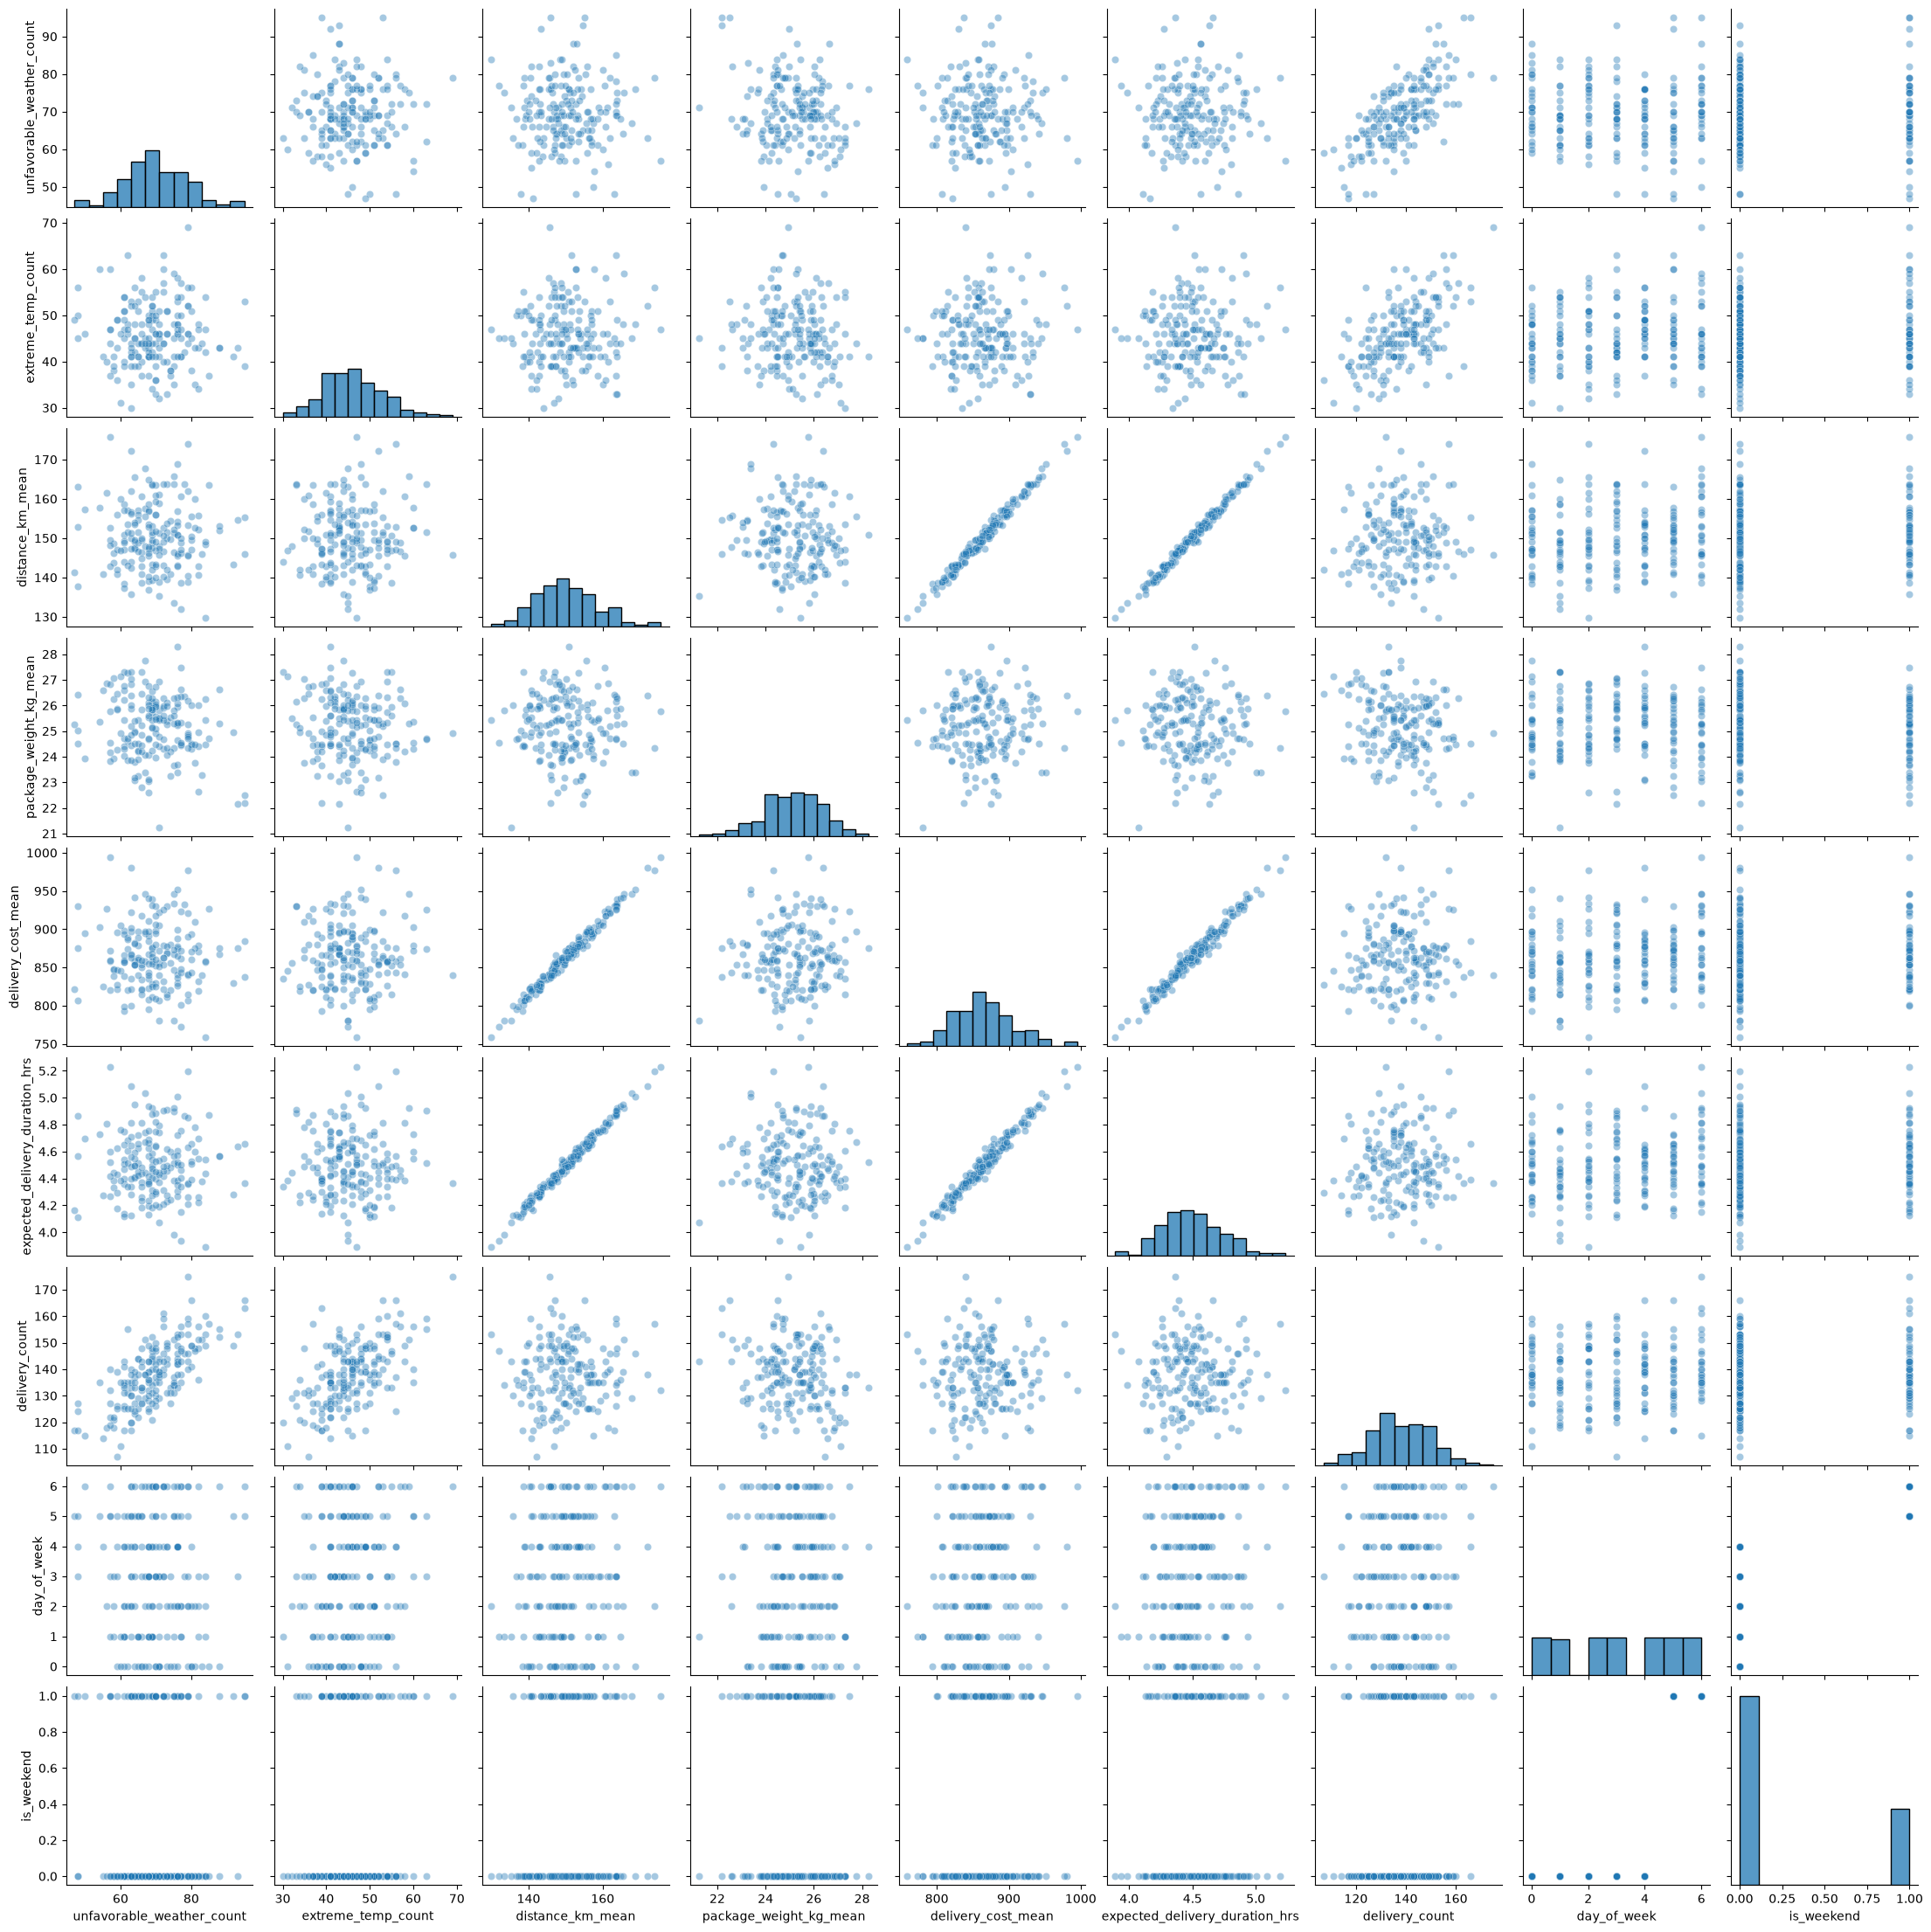

In [24]:
sns.pairplot(daily_demand_df, kind="scatter", plot_kws={'alpha' : 0.4})

In [25]:
daily_demand_df.describe()

,unfavorable_weather_count,extreme_temp_count,distance_km_mean,package_weight_kg_mean,delivery_cost_mean,expected_delivery_duration_hrs,delivery_count,day_of_week,is_weekend
count,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000,181.000000
mean,69.546961,45.790055,150.367422,25.168753,864.881379,4.502829,138.121547,3.011050,0.287293
std,8.761929,6.740434,8.261918,1.206269,41.311151,0.238155,11.897088,2.005517,0.453755
min,47.000000,30.000000,129.805882,21.242238,758.846261,3.890850,107.000000,0.000000,0.000000
25%,64.000000,41.000000,145.415909,24.394872,837.215571,4.353846,130.000000,1.000000,0.000000
50%,69.000000,45.000000,149.574815,25.269060,861.184679,4.490411,138.000000,3.000000,0.000000
75%,76.000000,50.000000,155.847682,26.011409,890.313076,4.647200,147.000000,5.000000,1.000000
max,95.000000,69.000000,175.658333,28.278722,994.748474,5.231818,175.000000,6.000000,1.000000


## 7. Save the modeling dataset

Export the cleaned, daily-level dataset in Pickle format for the modeling notebook.

In [26]:
daily_demand_df.to_pickle("../dataset/cleaned_dataset.pkl")